In [1]:
import csv

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

# Specify each path

In [12]:
dataset = '../model/keypoint_classifier/keypoint.csv'
model_save_path = '../model/keypoint_classifier/keypoint_classifier.keras'
tflite_save_path = '../model/keypoint_classifier/keypoint_classifier.tflite'

# Set number of classes

In [3]:
NUM_CLASSES = 28

# Dataset reading

In [6]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (21 * 2) + 1)))

In [7]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.75, random_state=RANDOM_SEED)

# Model building

In [9]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((21 * 2, )),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(20, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

In [10]:
model.summary()  # tf.keras.utils.plot_model(model, show_shapes=True)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout (Dropout)               │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 20)             │           860 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 28)             │           308 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,378 (5.38 KB)

 Trainable params: 1,378 (5.38 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Model checkpoint callback
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False)
# Callback for early stopping
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [14]:
# Model compilation
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model training

In [15]:
model.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback]
)

Epoch 1/1000
 1/15 ━━━━━━━━━━━━━━━━━━━━ 5s 411ms/step - accuracy: 0.0234 - loss: 3.3631
Epoch 1: saving model to ../model/keypoint_classifier/keypoint_classifier.keras

Epoch 1: finished saving model to ../model/keypoint_classifier/keypoint_classifier.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.0281 - loss: 3.3496 - val_accuracy: 0.0610 - val_loss: 3.2848
Epoch 2/1000
 1/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0625 - loss: 3.3005
Epoch 2: saving model to ../model/keypoint_classifier/keypoint_classifier.keras

Epoch 2: finished saving model to ../model/keypoint_classifier/keypoint_classifier.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0517 - loss: 3.3097 - val_accuracy: 0.1499 - val_loss: 3.2454
Epoch 3/1000
 1/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0547 - loss: 3.2528
Epoch 3: saving model to ../model/keypoint_classifier/keypoint_classifier.keras

Epoch 3: finished saving model to ../model/keypoint_classifier/keypoint_classifier.kera

In [16]:
# Model evaluation
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6030 - loss: 1.2946 


In [17]:
# Loading the saved model
model = tf.keras.models.load_model(model_save_path)

In [18]:
# Inference test
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
[1.08820655e-04 4.65041285e-06 1.14079021e-05 1.98436144e-04
 4.45885817e-03 6.65394546e-05 7.39469659e-03 4.61436139e-05
 7.37349956e-06 7.63592590e-03 2.99191179e-05 1.53591304e-06
 1.17297823e-04 4.05159267e-03 1.89420064e-06 2.77102052e-04
 1.31668061e-01 1.75251234e-02 1.24933416e-04 2.63041045e-07
 4.85605995e-07 1.36176322e-03 1.32305140e-03 5.24419500e-03
 8.26911801e-08 2.27974033e-06 8.00471067e-01 1.78664513e-02]
26


# Confusion matrix

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 804us/step


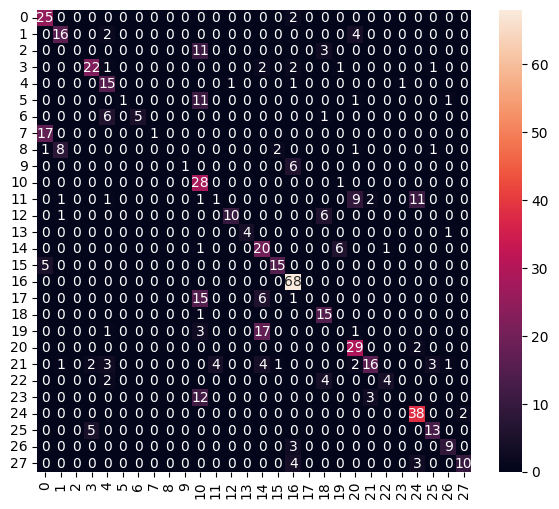

Classification Report
              precision    recall  f1-score   support

           0       0.52      0.93      0.67        27
           1       0.59      0.73      0.65        22
           2       0.00      0.00      0.00        14
           3       0.76      0.76      0.76        29
           4       0.48      0.83      0.61        18
           5       1.00      0.07      0.13        14
           6       1.00      0.42      0.59        12
           7       1.00      0.06      0.11        18
           8       0.00      0.00      0.00        13
           9       1.00      0.14      0.25         7
          10       0.34      0.97      0.50        29
          11       0.20      0.04      0.06        26
          12       0.91      0.59      0.71        17
          13       1.00      0.80      0.89         5
          14       0.41      0.71      0.52        28
          15       0.83      0.75      0.79        20
          16       0.78      1.00      0.88        68
     

c:\Users\theke\Documents\Code\bharatanatyam-mudra-classification\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\theke\Documents\Code\bharatanatyam-mudra-classification\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\theke\Documents\Code\bharatanatyam-mudra-classification\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` par

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
 
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)

# Convert to model for Tensorflow-Lite

In [21]:
# Save as a model dedicated to inference
model.save(model_save_path, include_optimizer=False)

In [22]:
# Transform model (quantization)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

INFO:tensorflow:Assets written to: C:\Users\theke\AppData\Local\Temp\tmpmf3u75l7\assets


INFO:tensorflow:Assets written to: C:\Users\theke\AppData\Local\Temp\tmpmf3u75l7\assets


Saved artifact at 'C:\Users\theke\AppData\Local\Temp\tmpmf3u75l7'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 42), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 28), dtype=tf.float32, name=None)
Captures:
  1521855042896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1521855042512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1521866518032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1521866520144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1521866520336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1521866517648: TensorSpec(shape=(), dtype=tf.resource, name=None)


7700

# Inference test

In [23]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

c:\Users\theke\Documents\Code\bharatanatyam-mudra-classification\.venv\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [24]:
# Get I / O tensor
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [25]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [26]:
%%time
# Inference implementation
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

CPU times: total: 0 ns
Wall time: 70.1 μs


In [27]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))

[1.0882053e-04 4.6504078e-06 1.1407911e-05 1.9843632e-04 4.4588600e-03
 6.6539447e-05 7.3946989e-03 4.6143479e-05 7.3734846e-06 7.6359292e-03
 2.9919171e-05 1.5359157e-06 1.1729781e-04 4.0515959e-03 1.8942039e-06
 2.7710176e-04 1.3166800e-01 1.7525138e-02 1.2493339e-04 2.6304176e-07
 4.8560690e-07 1.3617644e-03 1.3230524e-03 5.2442020e-03 8.2691486e-08
 2.2797446e-06 8.0047101e-01 1.7866466e-02]
26
